# Architecture of filters

So, the english is not very good, I will improve that

In [131]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from sympy.physics.quantum import TensorProduct

In [6]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution

In [7]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [8]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

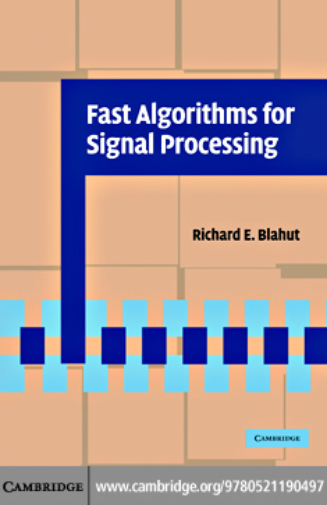

In [9]:
plot_pdf(doc[0], dpi=100)

## Polynomials

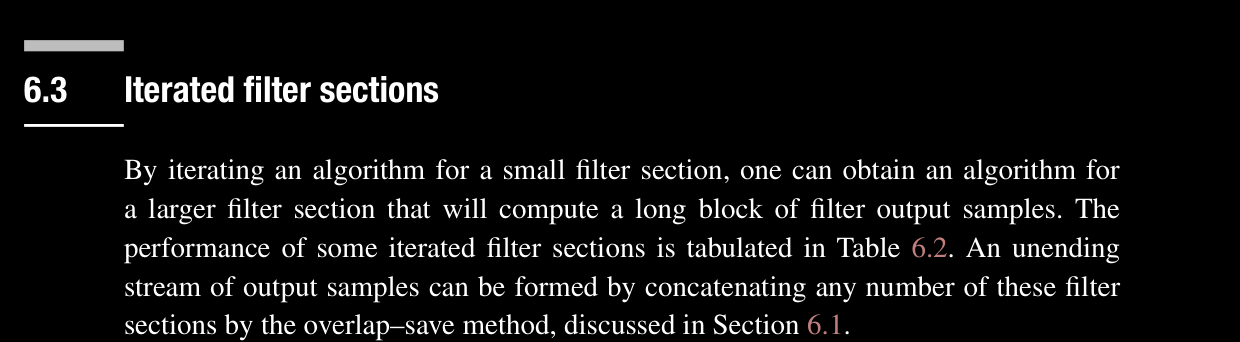

In [10]:
plot_pdf(doc[217], [.6, .78])

Size of vectors

In [11]:
v_size = 2

Example of vectors for the convolution

In [12]:
d_values = list(range(1, v_size+1))
g_values = list(range(1, v_size+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

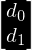

In [13]:
d0 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size))))
d0

In [14]:
g0 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size))))
g0

Just defining values of matrices

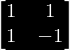

In [15]:
win = Matrix([[1, 1], [1, -1]])
win

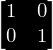

In [91]:
eye = sy.eye(2)
eye

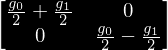

In [86]:
bg0 = sy.diag(*(win*g0*1/2).tolist())
bg0

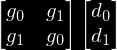

In [87]:
sy.MatMul(win * bg0 * win, d0)

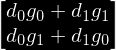

In [88]:
sy.MatMul(win, bg0, win, d0, evaluate=True)

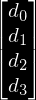

In [20]:
d1 = Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size*2))))
d1

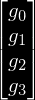

In [21]:
g1 = Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size*2))))
g1

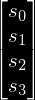

In [22]:
s0 = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(4))))
s0

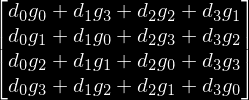

In [23]:
cc1 = Matrix(symmetrical_cyclic_convolution(np.array(d1).reshape(-1), np.array(g1).reshape(-1)))
cc1

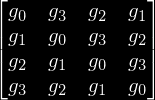

In [114]:
cc1_args = np.array([[arg for mul in line.args for arg in mul.args if 'g' in arg.name] for line in cc1])
Matrix(cc1_args)

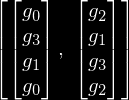

In [129]:
g1m = [
    Matrix(cc1_args[r:r+2, c:c+2].reshape(-1).tolist())
    for r in range(0, cc1_args.shape[0], 2)
    for c in range(0, cc1_args.shape[1]//2, 2)
]
g1m

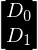

In [25]:
dd1 = Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(2))))
dd1

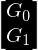

In [26]:
gg1 = Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(2))))
gg1

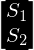

In [27]:
ss1 = Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(1, 3))))
ss1

In [31]:
d1m = [None for n in range(2)]
d1m

[None, None]

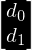

In [32]:
d1m[0] = Matrix([d1[0], d1[1]])
d1m[0]

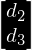

In [33]:
d1m[1] = Matrix([d1[2], d1[3]])
d1m[1]

In [34]:
ii = sy.symbols('I')
ii

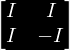

In [35]:
win_ii = Matrix([
    [ii, ii], 
    [ii, -ii]
])
win_ii

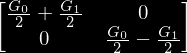

In [36]:
gg1m = sy.diag(*[
    gg1[0] + gg1[1], 
    gg1[0] - gg1[1]
])* 1/2
gg1m

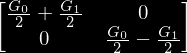

In [37]:
sy.diag(*(win * gg1/2).flat())

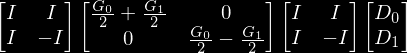

In [38]:
sy.MatMul(win_ii, gg1m, win_ii, dd1)

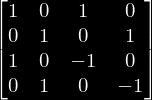

In [92]:
win1 = TensorProduct(win, eye)
win1

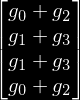

In [126]:
g1m[0]+g1m[1]

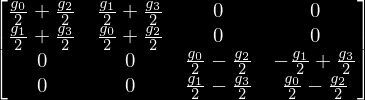

In [41]:
bg1 = sy.diag(*[
    g1m[0] + g1m[1], 
    g1m[0] - g1m[1]
])* 1/2
bg1

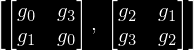

In [104]:
g1m

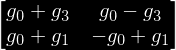

In [103]:
TensorProduct(g1m[0] * win)

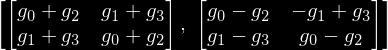

In [42]:
[g1m[0]*win[0,0] + g1m[1]*win[0,1], g1m[0]*win[0,1] + g1m[1]*win[1,1]]

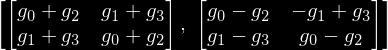

In [43]:
[(g1m[0]*win[r, 0] + g1m[1]*win[r, 1]) for r in range(2)]

In [44]:
g1m[0][0, :] + g1m[1][0, :]

In [45]:
g1m[0][0, :] - g1m[1][0, :]

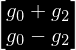

In [46]:
win * Matrix([
    g1[0], g1[2]
])

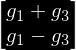

In [47]:
win * Matrix([
    g1[1], g1[3]
])

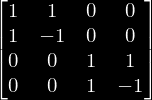

In [130]:
win1g = TensorProduct(eye, win)
win1g

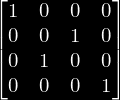

In [138]:
s42 = Matrix([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1]
])
s42

In [ ]:
s42 = Matrix([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1]
])
s42

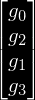

In [139]:
g1_kr = s42 * g1
g1_kr

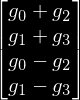

In [147]:
bg1b = s42 * win1g * g1_kr
bg1b

In [160]:
sbg0 = Matrix([
    [1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 1, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, -1],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0],
])

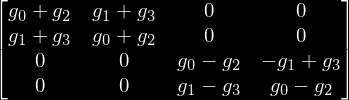

In [162]:
bg1mc = sbg0 * bg1b
bg1mc.reshape(4,4)

A organização dessa tabela está um pouco confusa ainda mas é igual as tabelas $m1$ e $m2$ das variáveis $x'$, página 3 coluna 1, de Diaz-Perez

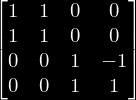

In [51]:
win1g2 = Matrix([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 1, -1],
    [0, 0, 1, 1],
])
win1g2

Não funcionou, mas sem problema por enquanto pegamos os resultados e reorganizamos na nova matriz

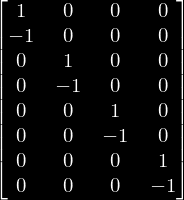

In [53]:
win1g2 = Matrix([
    [1, 0, 0, 0],
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, -1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, -1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, -1],

])
win1g2

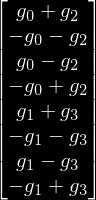

In [54]:
win1g2 * win1g * g1_kr

In [57]:
# gt = - g0[1] + g0[3]
# gt

In [58]:
# gt * -1

4 multipliações apenas, uma delas com uma inversão

fazer uma matriz vertical com as somas de g e uma matriz quase identidade com as multiplicações de g

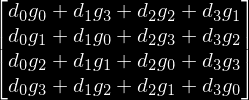

In [59]:
cc = Matrix(symmetrical_cyclic_convolution(np.array(d1).reshape(-1), np.array(g1).reshape(-1)))
cc

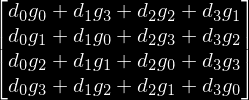

In [60]:
ssx = sy.MatMul(win1, bg1, win1, d1, evaluate=True)
ssx

In [61]:
np.all(np.array(cc) == np.array(ssx))

True

In [164]:
ssx = sy.MatMul(win1, sbg0.reshape(4,4, 4), s42, win1g, s42, g1, win1, d1, evaluate=True)
ssx

ValueError: Invalid reshape parameters 4 4

In [62]:
# dd_mtx * d0

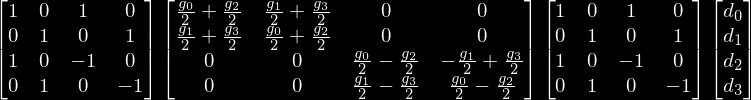

In [63]:
ssx = sy.MatMul(win1, bg1, win1, d1)
ssx

In [64]:
subs = {k: v for k, v in zip(g1.flat(), range(0, len(g1.flat())))}
subs

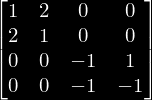

In [65]:
bg1_subs = bg1.subs(subs)
bg1_subs

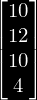

In [66]:
Matrix(symmetrical_cyclic_convolution(range(len(d1.flat())), range(len(g1.flat()))))

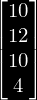

In [67]:
r = win1 * bg1_subs * win1 * Matrix([0, 1, 2, 3])
r

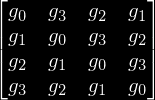

In [68]:
# win1, bg1
win1 * bg1 * win1